# Phase 5: Model Evaluation and Hyperparameter Tuning

### Step 1: Loading Data and Best Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('../data/processed/engineered_dengue_weather.csv')

X = df.drop(columns=['Month', 'Year', 'Region', 'Dengue_Cases', 'Dengue_Deaths', 'Date', 'Is_Outbreak'])
y = df['Is_Outbreak']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 2: Hyperparameter Tuning with Grid Search

In [2]:
# Tuning Random Forest (The Ensemble Method)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_model = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)
print("Best Cross-Validation Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.7757294628161006


### Step 3: Final Model Evaluation

In [3]:
y_pred = best_model.predict(X_test)

print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Set Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       153
           1       0.50      0.37      0.43        51

    accuracy                           0.75       204
   macro avg       0.65      0.62      0.63       204
weighted avg       0.73      0.75      0.74       204



### Step 4: Confusion Matrix Visualization

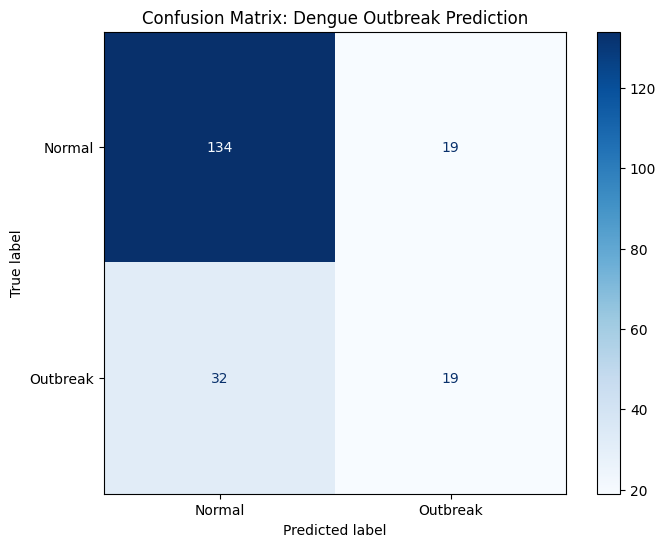

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Outbreak'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Dengue Outbreak Prediction')
plt.show()

### Step 5: Feature Importance

C:\Users\BUENVIAJE\AppData\Local\Temp\ipykernel_104676\2285114354.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


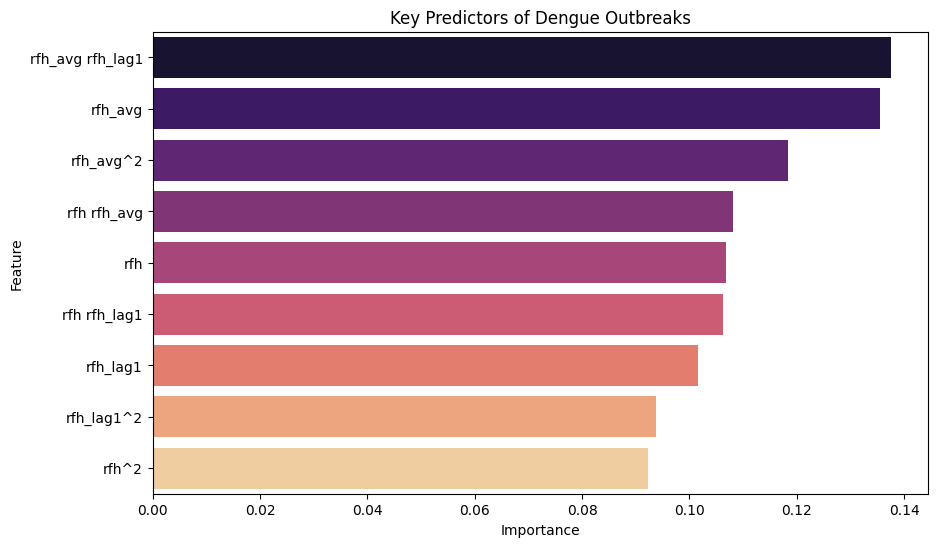

In [5]:
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Key Predictors of Dengue Outbreaks')
plt.show()

### Step 6: Exporting the Final Model

In [6]:
os.makedirs('../models/', exist_ok=True)

with open('../models/dengue_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model successfully saved to ../models/dengue_model.pkl")

Model successfully saved to ../models/dengue_model.pkl
